# Historical synthetic prior plus MBDoE 2026 Lot 2

## tl;dr

This notebook measures how much the executed synthetic-must Lot 2 campaign changes calibration and practical estimability relative to the existing historical synthetic-must prior. It distinguishes observed-data information from the still-conditional CO2 flow schedule and keeps unsupported aroma directions visible rather than regularizing them into apparent identifiability.

## Context & Methods

### Key assumptions

The observed-data Fisher information matrix is computed in log-parameter coordinates,

$$F(\theta)=J(\theta)^\mathsf{T}J(\theta),\qquad
J_{ij}=\frac{\partial r_i}{\partial\log\theta_j}.$$

The prior and Lot 2 contributions are evaluated at the same combined optimum to obtain

$$F_{\mathrm{combined}}=F_{\mathrm{historical}}+F_{\mathrm{Lot2}}.$$

This decomposition separates new experimental information from changes caused only by moving the parameter estimate. The core kinetic block and reduced secondary block are re-estimated sequentially. Profile likelihood is used for selected core parameters because local FIM uncertainty alone cannot establish bounded confidence intervals.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
while ROOT.name != "pyomo-doe" and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if ROOT.name != "pyomo-doe":
    raise RuntimeError("Run this notebook from inside the pyomo-doe repository")

import sys
FERMENTATION_MODEL = ROOT / "fermentation_model"
if str(FERMENTATION_MODEL) not in sys.path:
    sys.path.insert(0, str(FERMENTATION_MODEL))

from laboratory_2026 import run_estimability_historical_synthetic_plus_lot2 as analysis

analysis.run_analysis(reuse_if_current=True)
summary = json.loads((analysis.RESULTS_DIR / "summary.json").read_text(encoding="utf-8"))
summary

[resume] source fingerprint unchanged; using completed result set


[done] historical synthetic plus Lot 2 analysis complete


{'n_historical_synthetic_batches': 10,
 'n_lot2_batches': 3,
 'n_combined_batches': 13,
 'n_core_parameters_reestimated': 11,
 'n_secondary_parameters_reestimated': 6,
 'n_extended_parameters_screened': 26,
 'n_lot2_co2_information_times': 48,
 'co2_values_used_in_fit': False,
 'fim_decomposition_relative_error': 0.0,
 'profile_parameters': ['Kd0', 'qN'],
 'fit_nfev': 450,
 'secondary_nfev': 300,
 'profile_nfev': 50,
 'grid_points': 3,
 'finite_difference_log_step': 0.04,
 'source_fingerprint': 'ccc275e37d8d16e41373f0f67e8c3c731727b74ba7f223b5ef71c9f7c9dadb49'}

## Data

In [2]:
support = pd.read_csv(analysis.RESULTS_DIR / "lot2_measurement_support.csv")
batch_summary = pd.read_csv(analysis.RESULTS_DIR / "batch_summary.csv")
display(batch_summary.groupby("case").agg(n_batches=("batch", "nunique"), n_core_obs=("n_core_obs", "sum"), n_secondary_obs=("n_secondary_obs", "sum")))
display(support.pivot_table(index="state", values="n_observations", aggfunc="sum"))

,n_batches,n_core_obs,n_secondary_obs
case,,,
historical_synthetic,10,542,86
historical_synthetic_plus_lot2,13,849,215
lot2_added,3,307,129


,n_observations
state,
AcAld,41
Acetate,44
E,36
F,44
G,44
Gly,42
N,43
O2,0
Pyr,44


## Results

In [3]:
fit = pd.read_csv(analysis.RESULTS_DIR / "fit_summary.csv")
secondary_fit = pd.read_csv(analysis.RESULTS_DIR / "secondary_fit_summary.csv")
metrics = pd.read_csv(analysis.RESULTS_DIR / "fim_metrics.csv")
comparison = pd.read_csv(analysis.RESULTS_DIR / "estimability_change_historical_vs_plus_lot2.csv")
profiles = pd.read_csv(analysis.RESULTS_DIR / "profile_likelihood_summary_combined.csv")
display(fit)
display(secondary_fit)
display(metrics)
display(comparison.sort_values("std_log_ratio_combined_over_historical").head(15))
display(profiles)

,fit,n_batches,mediums,parameters,n_parameters,success,status,message,nfev,initial_wsse,final_wsse,n_residuals,dof,wsse_per_residual,wsse_per_dof,l2_lambda,l2_parameters,best_seed
0,historical_synthetic,10,synthetic,"mu0,qN,betaG0,betaF0,qEG,qEF,iG,iE,Kd0,gammaG0...",11,True,3,`xtol` termination condition is satisfied.,7,9304.154690,9302.472794,542,531,17.163234,17.518781,0.0,NaN,profile_center_Kd0_release
1,historical_synthetic_plus_lot2,13,synthetic,"mu0,qN,betaG0,betaF0,qEG,qEF,iG,iE,Kd0,gammaG0...",11,True,3,`xtol` termination condition is satisfied.,24,26389.031254,17876.911224,849,838,21.056433,21.332830,0.0,NaN,seed_default


,case,model,success,status,message,nfev,initial_wsse,final_wsse,n_residuals,wsse_per_residual
0,historical_synthetic,historical_synthetic,True,2,`ftol` termination condition is satisfied.,18,914.870786,596.654369,86,6.937841
1,historical_synthetic_plus_lot2,historical_synthetic_plus_lot2,True,2,`ftol` termination condition is satisfied.,14,7237.919866,3996.700493,215,18.589305


,logdet,min_eigenvalue,max_eigenvalue,min_relative_eigenvalue,condition_number,trace_inv,rank_1e-8,case,block,n_parameters
0,-105.619503,0.000000,94986.564401,0.000000,1.000000e+12,1.773148e+06,13,historical_observed_only_at_historical_theta,extended,26
1,-92.127104,0.000000,136088.977901,0.000000,1.000000e+12,1.463333e+06,14,historical_component_at_combined_theta,extended,26
2,-51.450633,0.000000,39354.176039,0.000000,1.000000e+12,3.165141e+06,17,lot2_increment_observed_only_at_combined_theta,extended,26
3,-15.804060,0.000000,171848.666468,0.000000,1.000000e+12,8.149270e+05,17,combined_observed_only_at_combined_theta,extended,26
4,-51.035744,0.000000,40099.528889,0.000000,1.000000e+12,3.105531e+06,17,lot2_increment_observed_plus_co2_schedule_at_c...,extended,26
5,-15.692519,0.000000,172219.279323,0.000000,1.000000e+12,8.109194e+05,17,combined_observed_plus_co2_schedule_at_combine...,extended,26
6,82.865752,8.084582,165350.247741,0.000049,2.045254e+04,1.580970e-01,11,historical_synthetic_plus_lot2,core,11
7,124.385805,8.302358,171848.666468,0.000048,2.069878e+04,2.111061e-01,17,historical_synthetic_plus_lot2,core_secondary_observed,17


,case_historical,parameter,theta_historical,std_log_historical,approx_95_multiplier_historical,active_bound_historical,classification_historical,case_combined,theta_combined,std_log_combined,approx_95_multiplier_combined,active_bound_combined,classification_combined,std_log_ratio_combined_over_historical,dispersion_scale_combined,std_log_dispersion_adjusted,approx_95_multiplier_dispersion_adjusted,classification_dispersion_adjusted
14,historical_synthetic,kAldS_N,2.359888,382.212239,1.057654e+17,False,weak_or_confounded,historical_synthetic_plus_lot2,7.469772,0.028890,1.058258e+00,False,well_estimated,0.000076,4.311532,0.124560,1.276519,well_estimated
15,historical_synthetic,kAcAld,0.001392,382.212239,1.057654e+17,False,weak_or_confounded,historical_synthetic_plus_lot2,0.022310,0.037813,1.076929e+00,False,well_estimated,0.000099,4.311532,0.163031,1.376496,well_estimated
16,historical_synthetic,kAcStress,0.002616,382.212239,1.057654e+17,False,weak_or_confounded,historical_synthetic_plus_lot2,0.005285,0.039282,1.080035e+00,False,well_estimated,0.000103,4.311532,0.169366,1.393694,well_estimated
10,historical_synthetic,gammaF0,0.000101,141.822164,1.057654e+17,True,weak_or_confounded,historical_synthetic_plus_lot2,0.033532,0.339697,1.946060e+00,False,well_estimated,0.002395,4.618748,1.568977,21.654093,weak_or_confounded
11,historical_synthetic,kPyrS_N,0.764162,0.047208,1.096943e+00,False,well_estimated,historical_synthetic_plus_lot2,2.310935,0.030396,1.061386e+00,False,well_estimated,0.643875,4.311532,0.131053,1.292869,well_estimated
2,historical_synthetic,betaG0,1.148988,0.058487,1.121463e+00,False,well_estimated,historical_synthetic_plus_lot2,1.329860,0.041733,1.085235e+00,False,well_estimated,0.713542,4.618748,0.192753,1.459066,well_estimated
4,historical_synthetic,qEG,2.356897,0.044507,1.091151e+00,False,well_estimated,historical_synthetic_plus_lot2,2.577082,0.033058,1.066938e+00,False,well_estimated,0.742754,4.618748,0.152684,1.348862,well_estimated
7,historical_synthetic,iE,0.067913,0.058840,1.122241e+00,False,well_estimated,historical_synthetic_plus_lot2,0.055470,0.043906,1.089866e+00,False,well_estimated,0.746181,4.618748,0.202789,1.488049,well_estimated
0,historical_synthetic,mu0,0.050000,0.014402,1.028630e+00,True,weak_or_confounded,historical_synthetic_plus_lot2,0.133609,0.011288,1.022372e+00,False,well_estimated,0.783816,4.618748,0.052139,1.107596,well_estimated
23,historical_synthetic,alpha_EA_loss,1.000000,382.212239,1.057654e+17,False,weak_or_confounded,historical_synthetic_plus_lot2,1.000000,300.910989,1.057654e+17,False,weak_or_confounded,0.787288,NaN,NaN,NaN,unsupported_by_current_measurements


,case,parameter,n_success,max_lr_stat,crosses_left_95,crosses_right_95,profile_identifiable_95,chi2_95_threshold
0,historical_synthetic_plus_lot2,Kd0,4,294.654016,True,True,True,3.841459
1,historical_synthetic_plus_lot2,qN,4,1796.963641,True,True,True,3.841459


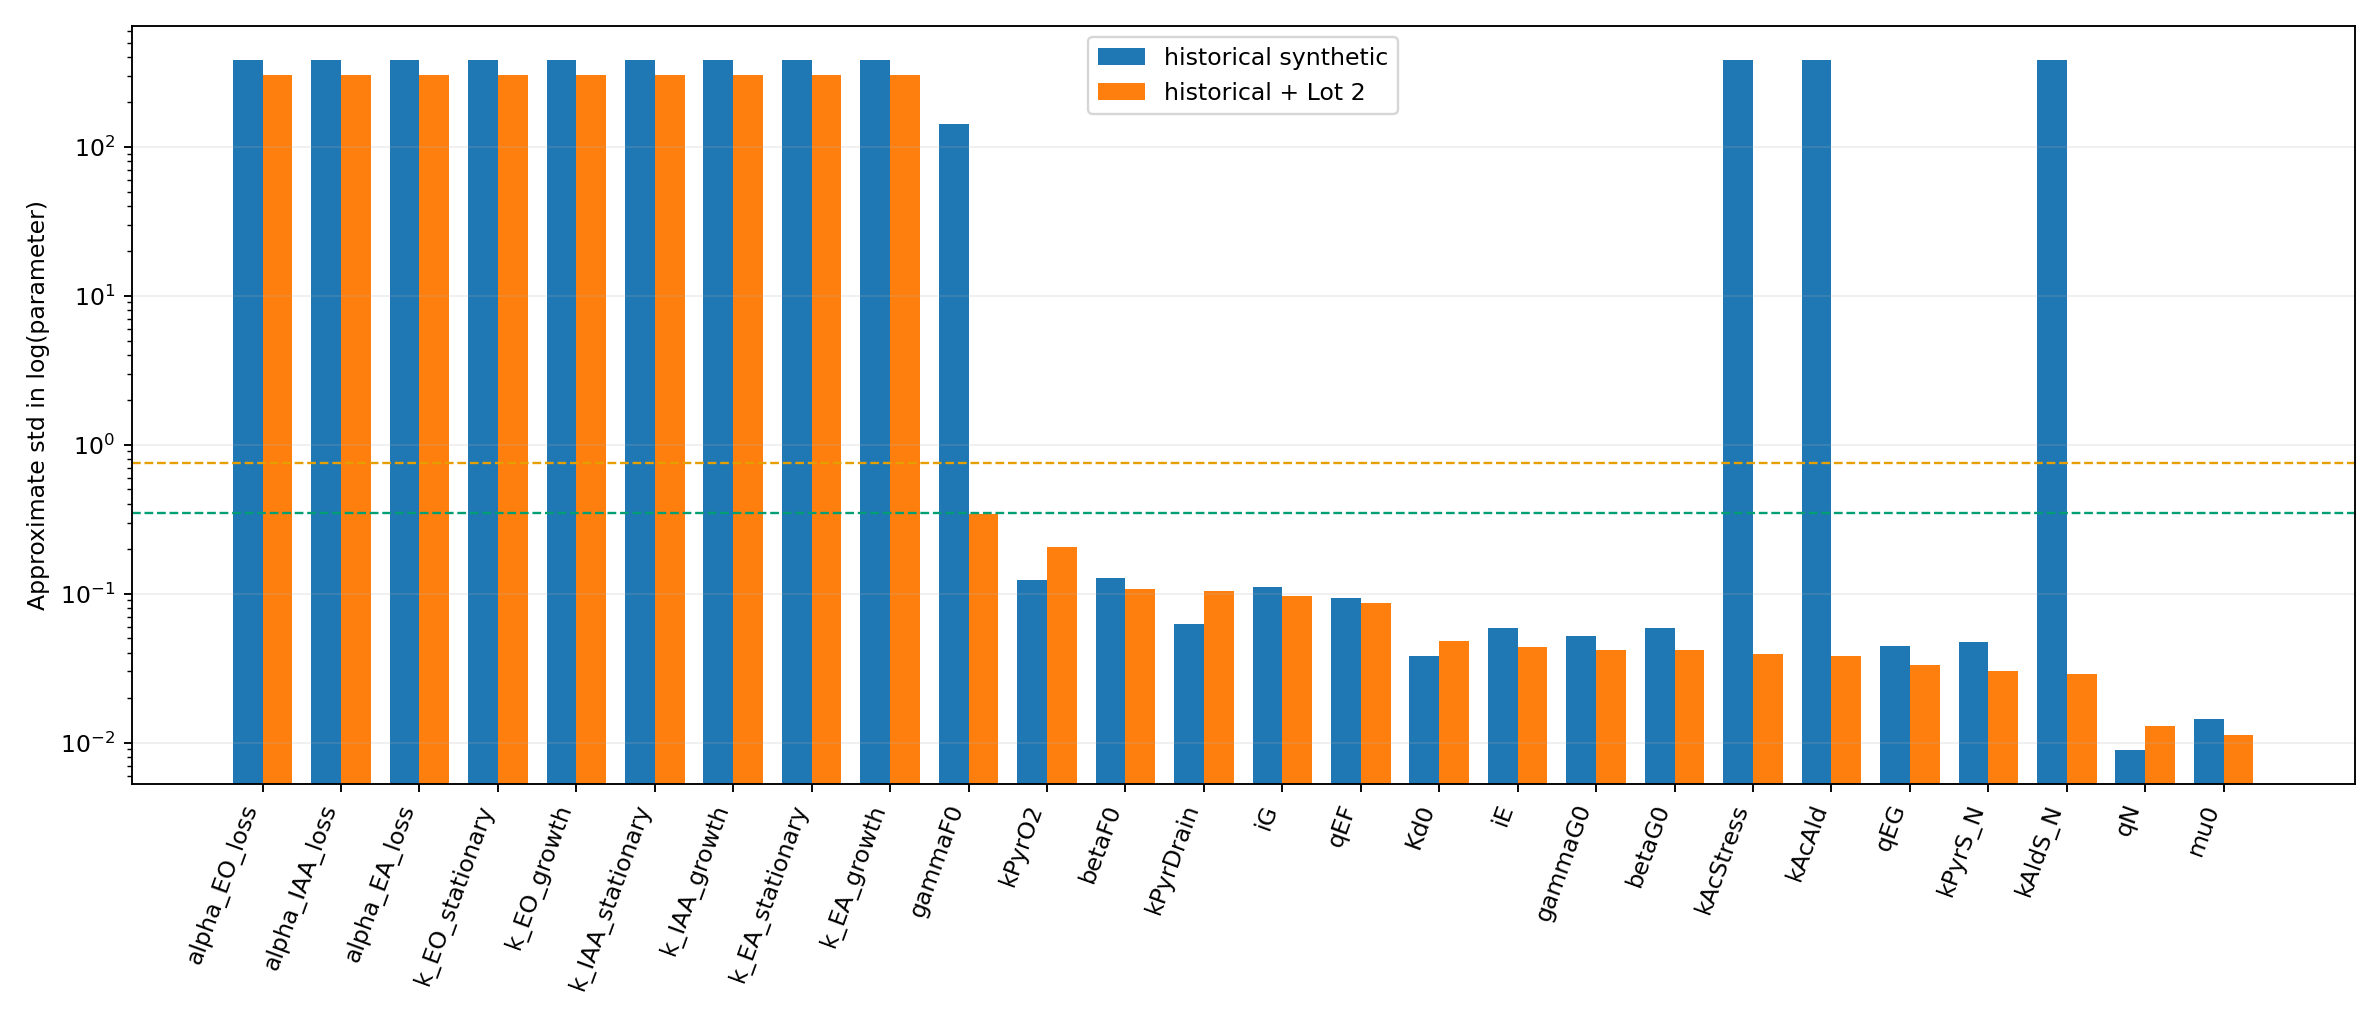

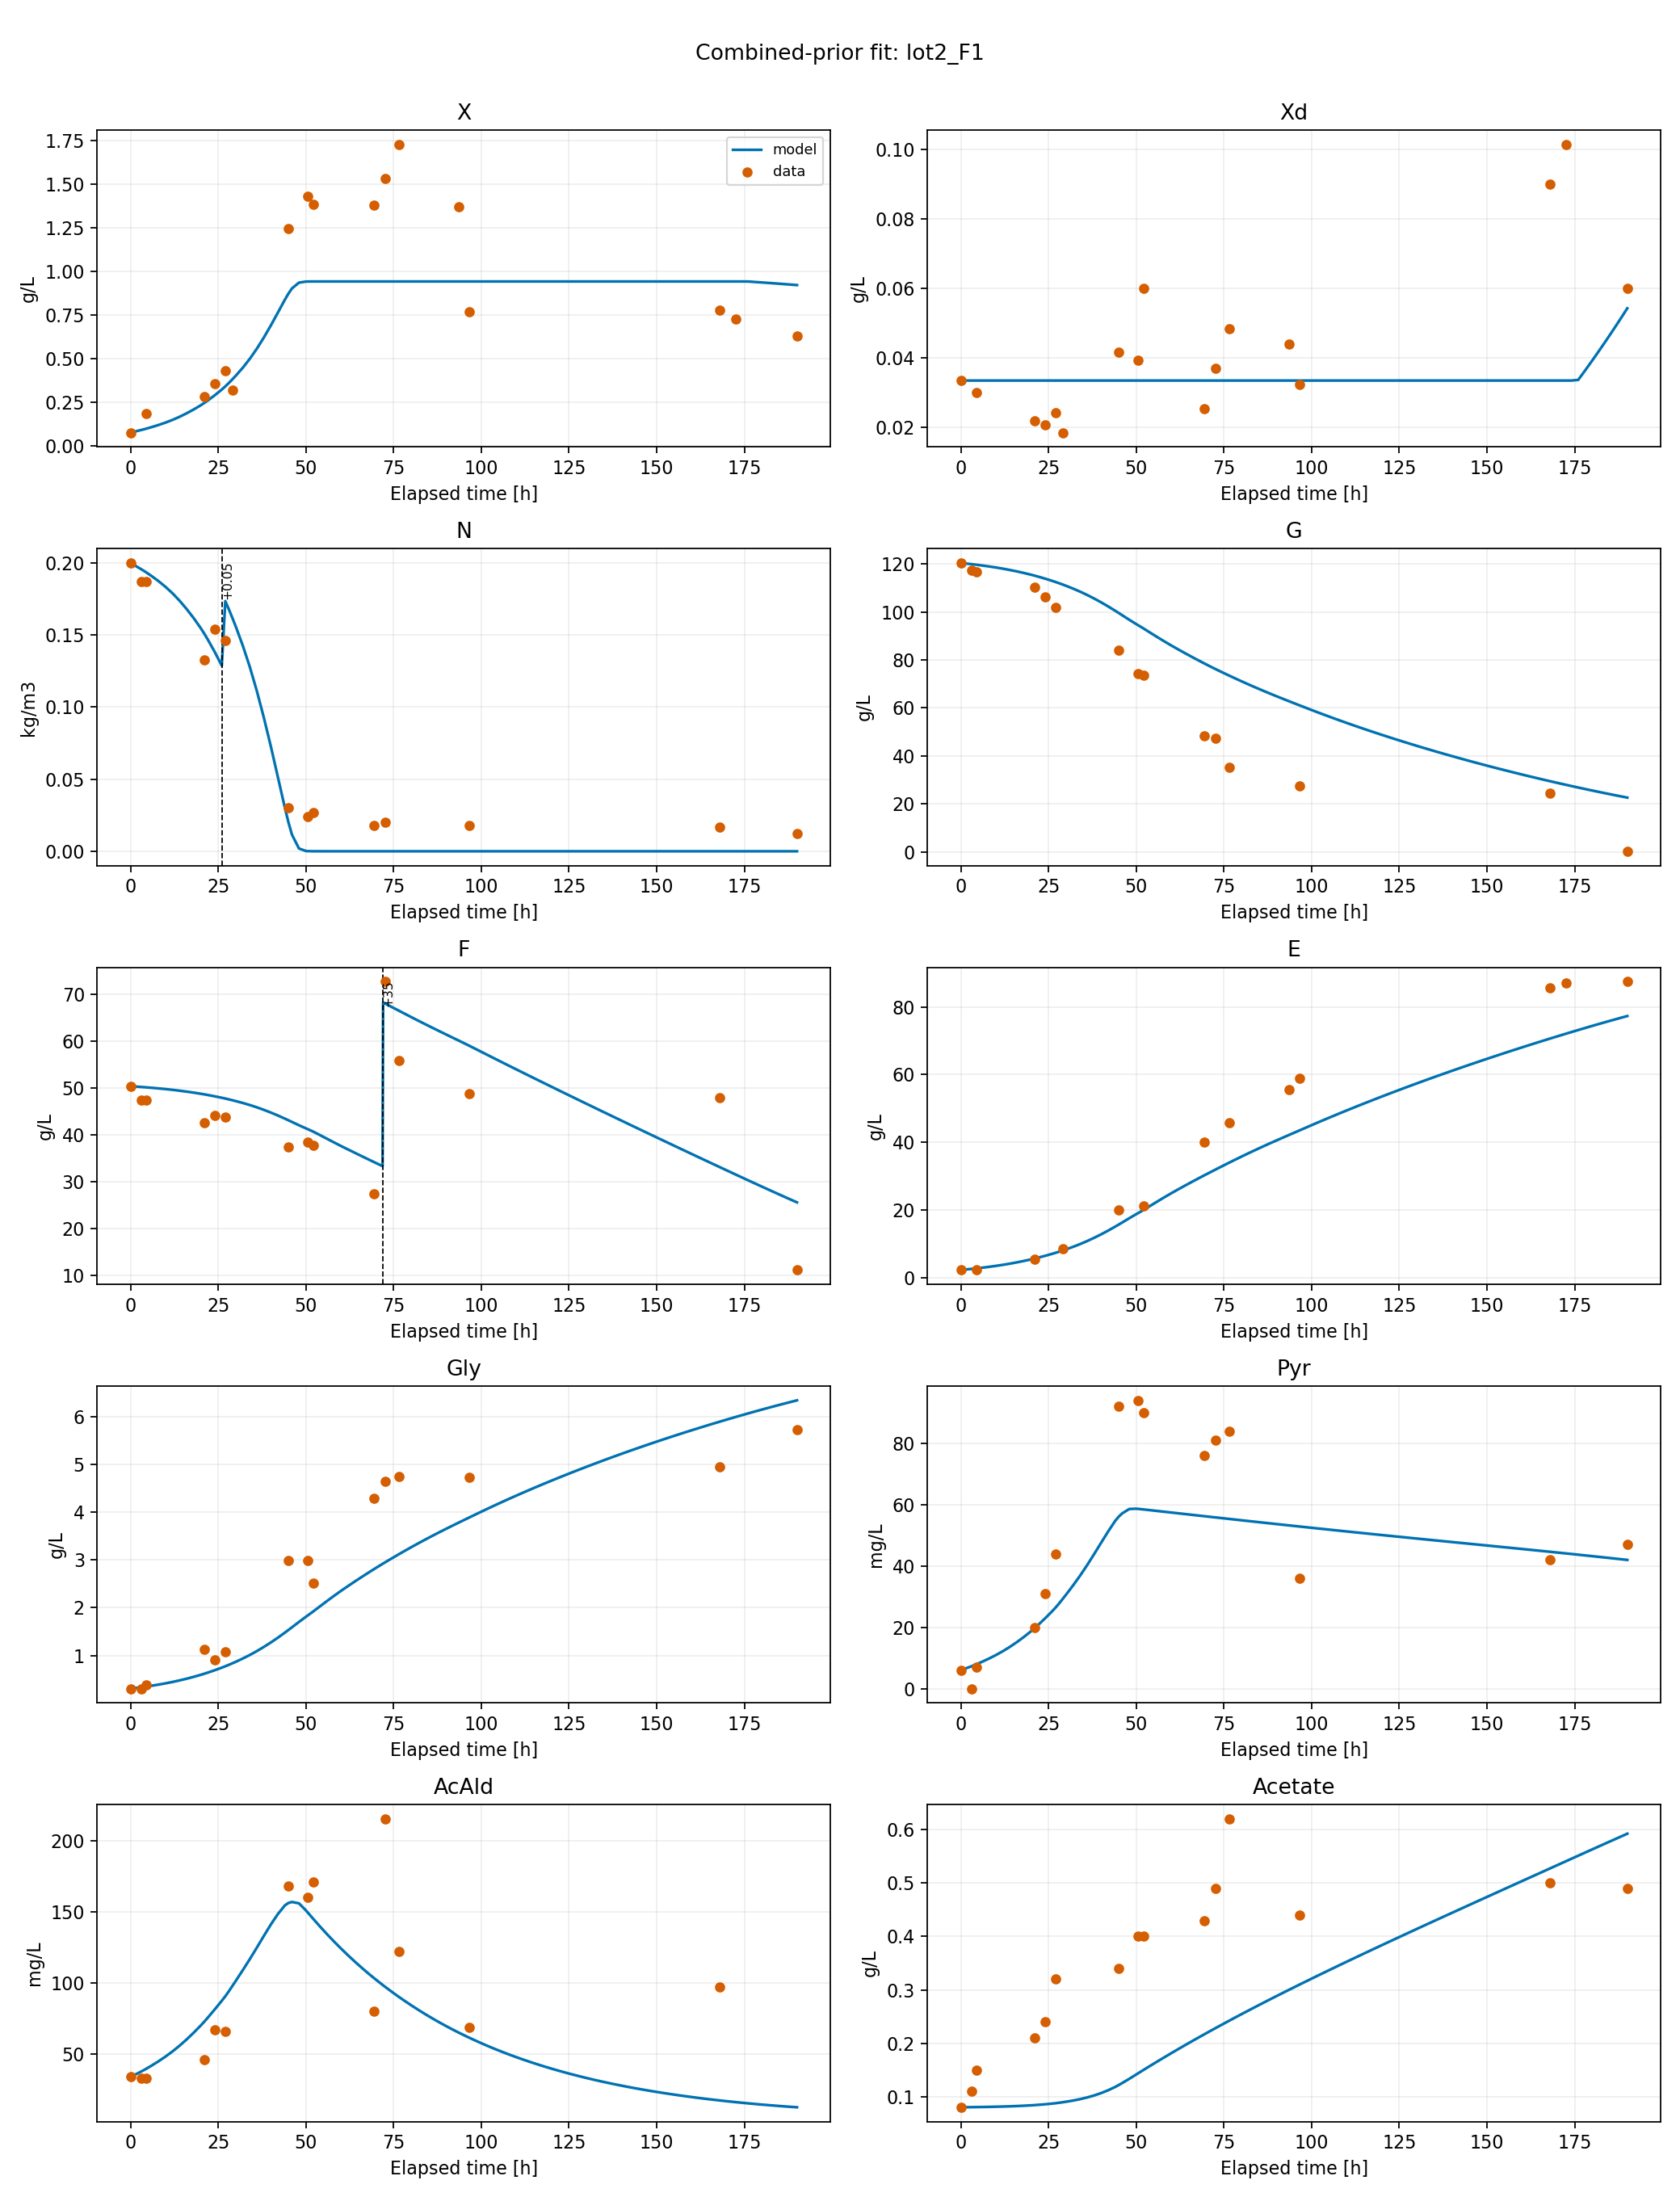

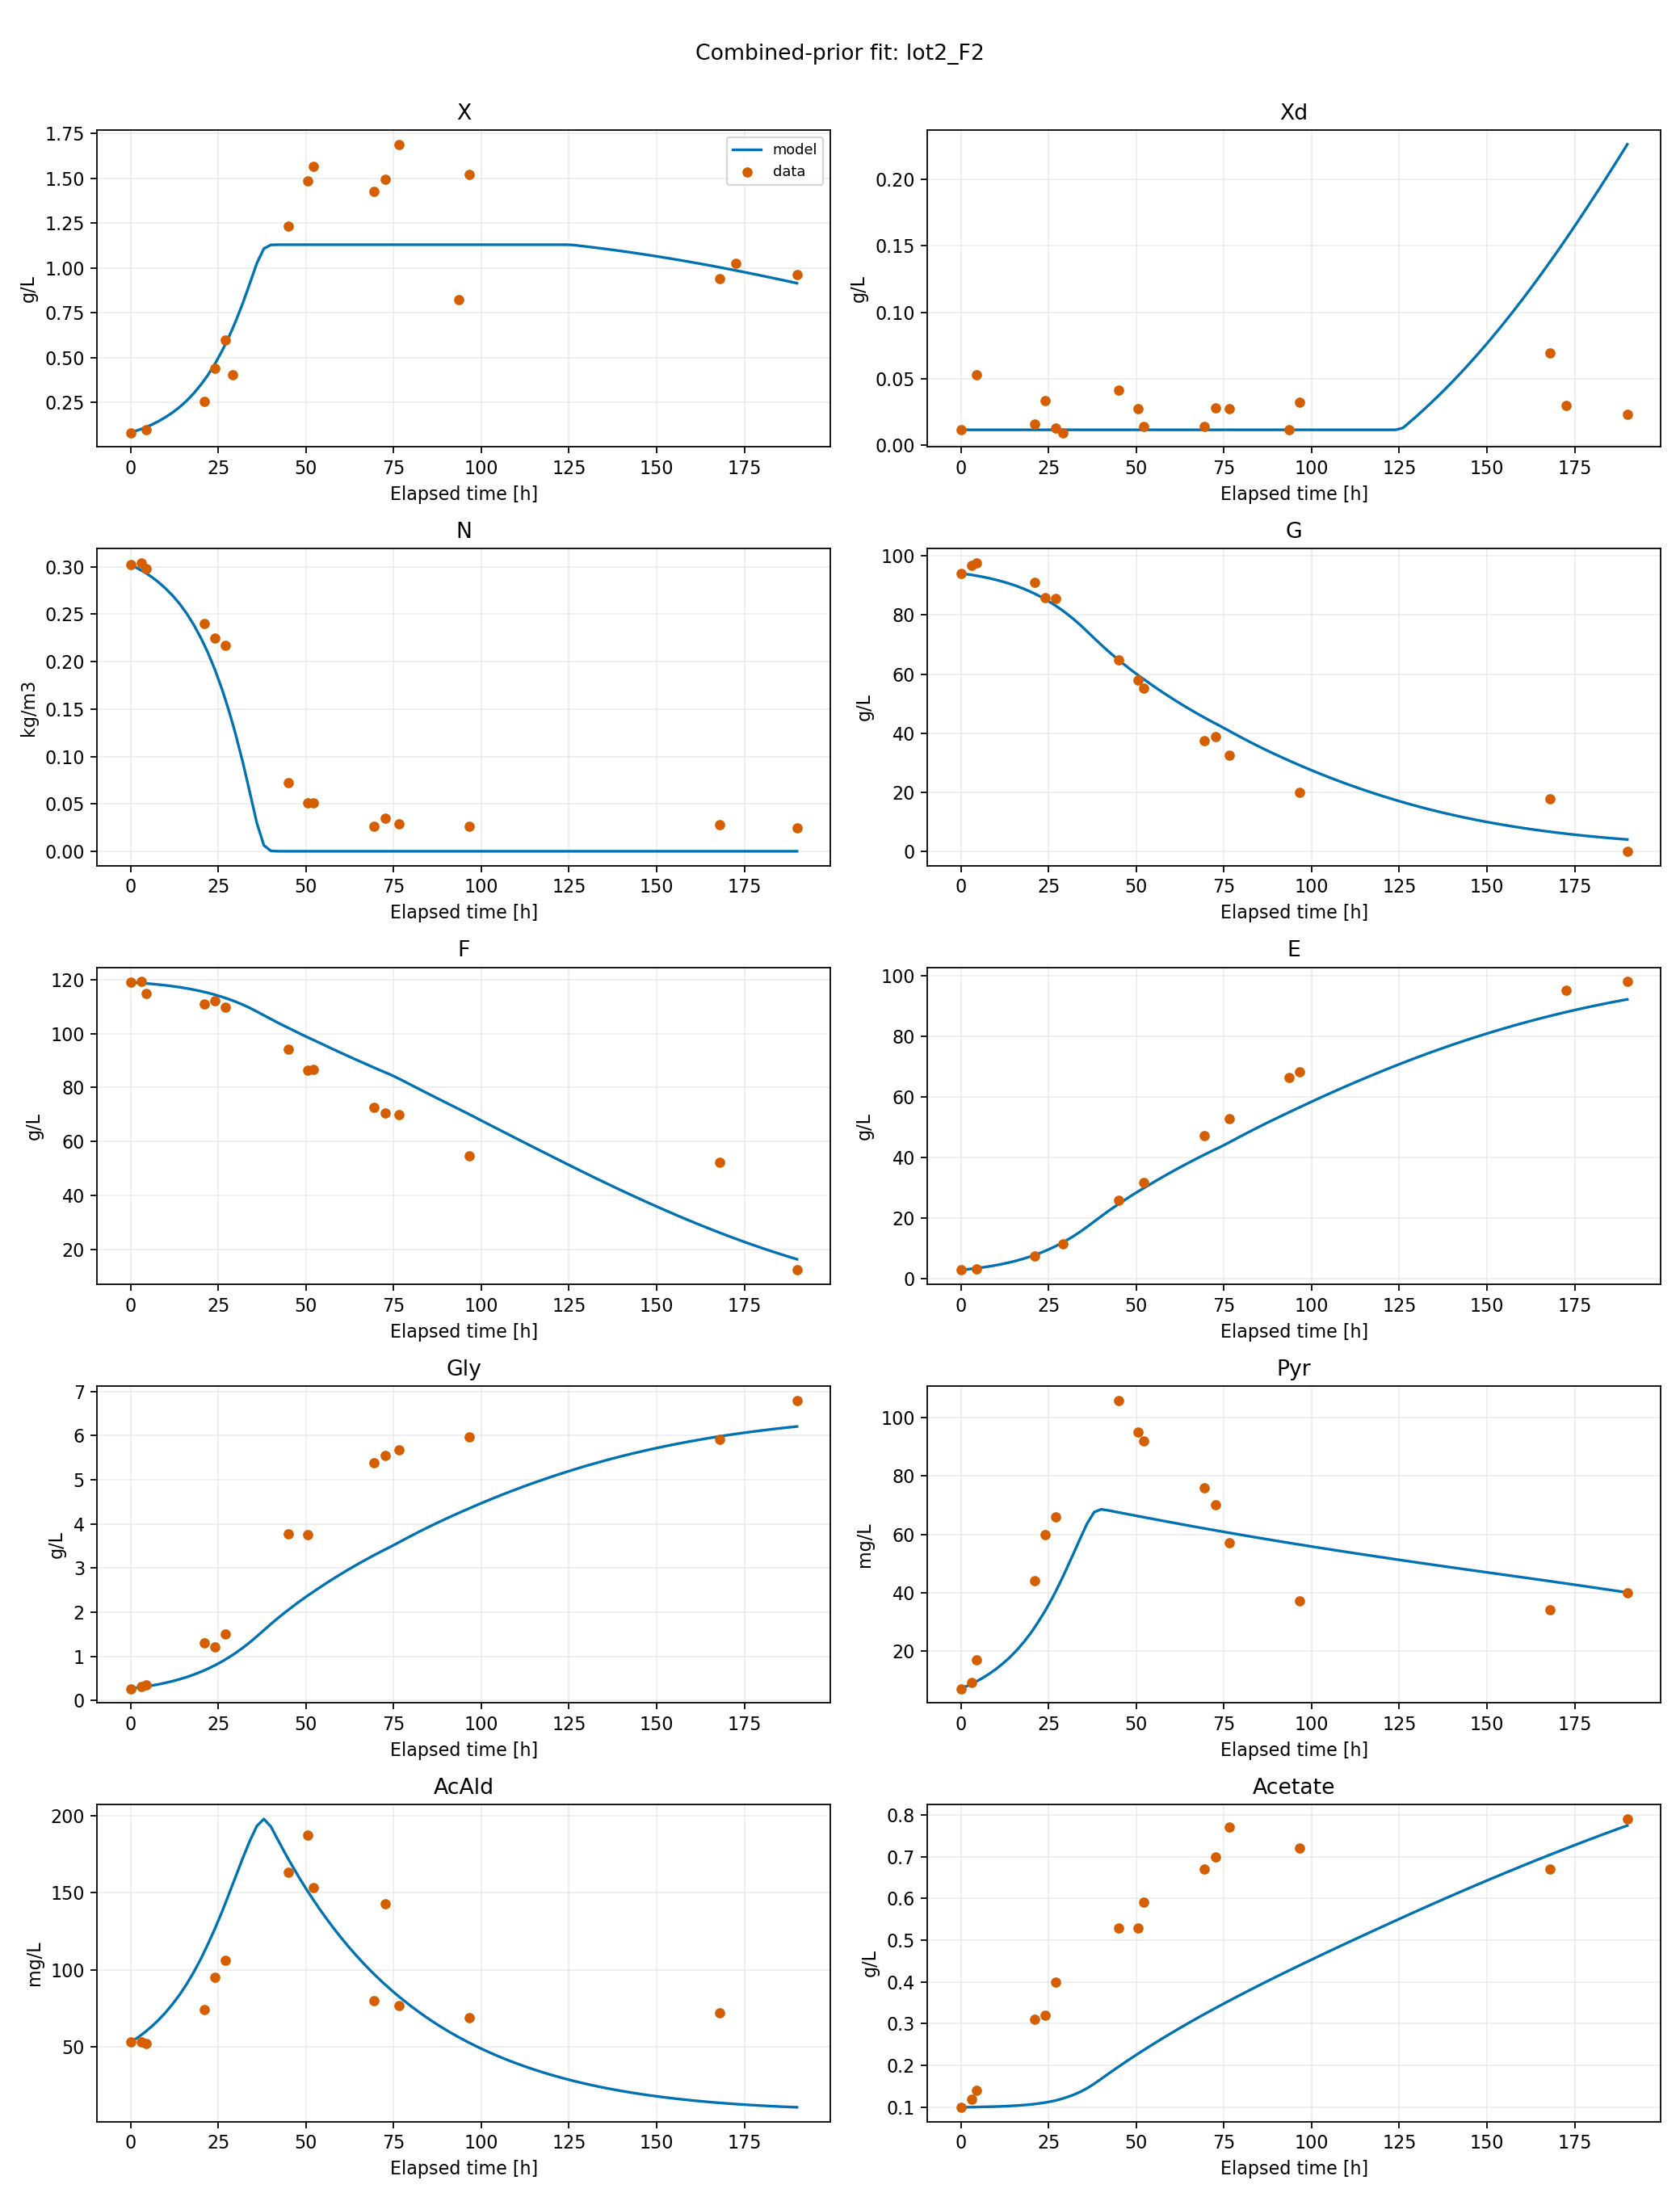

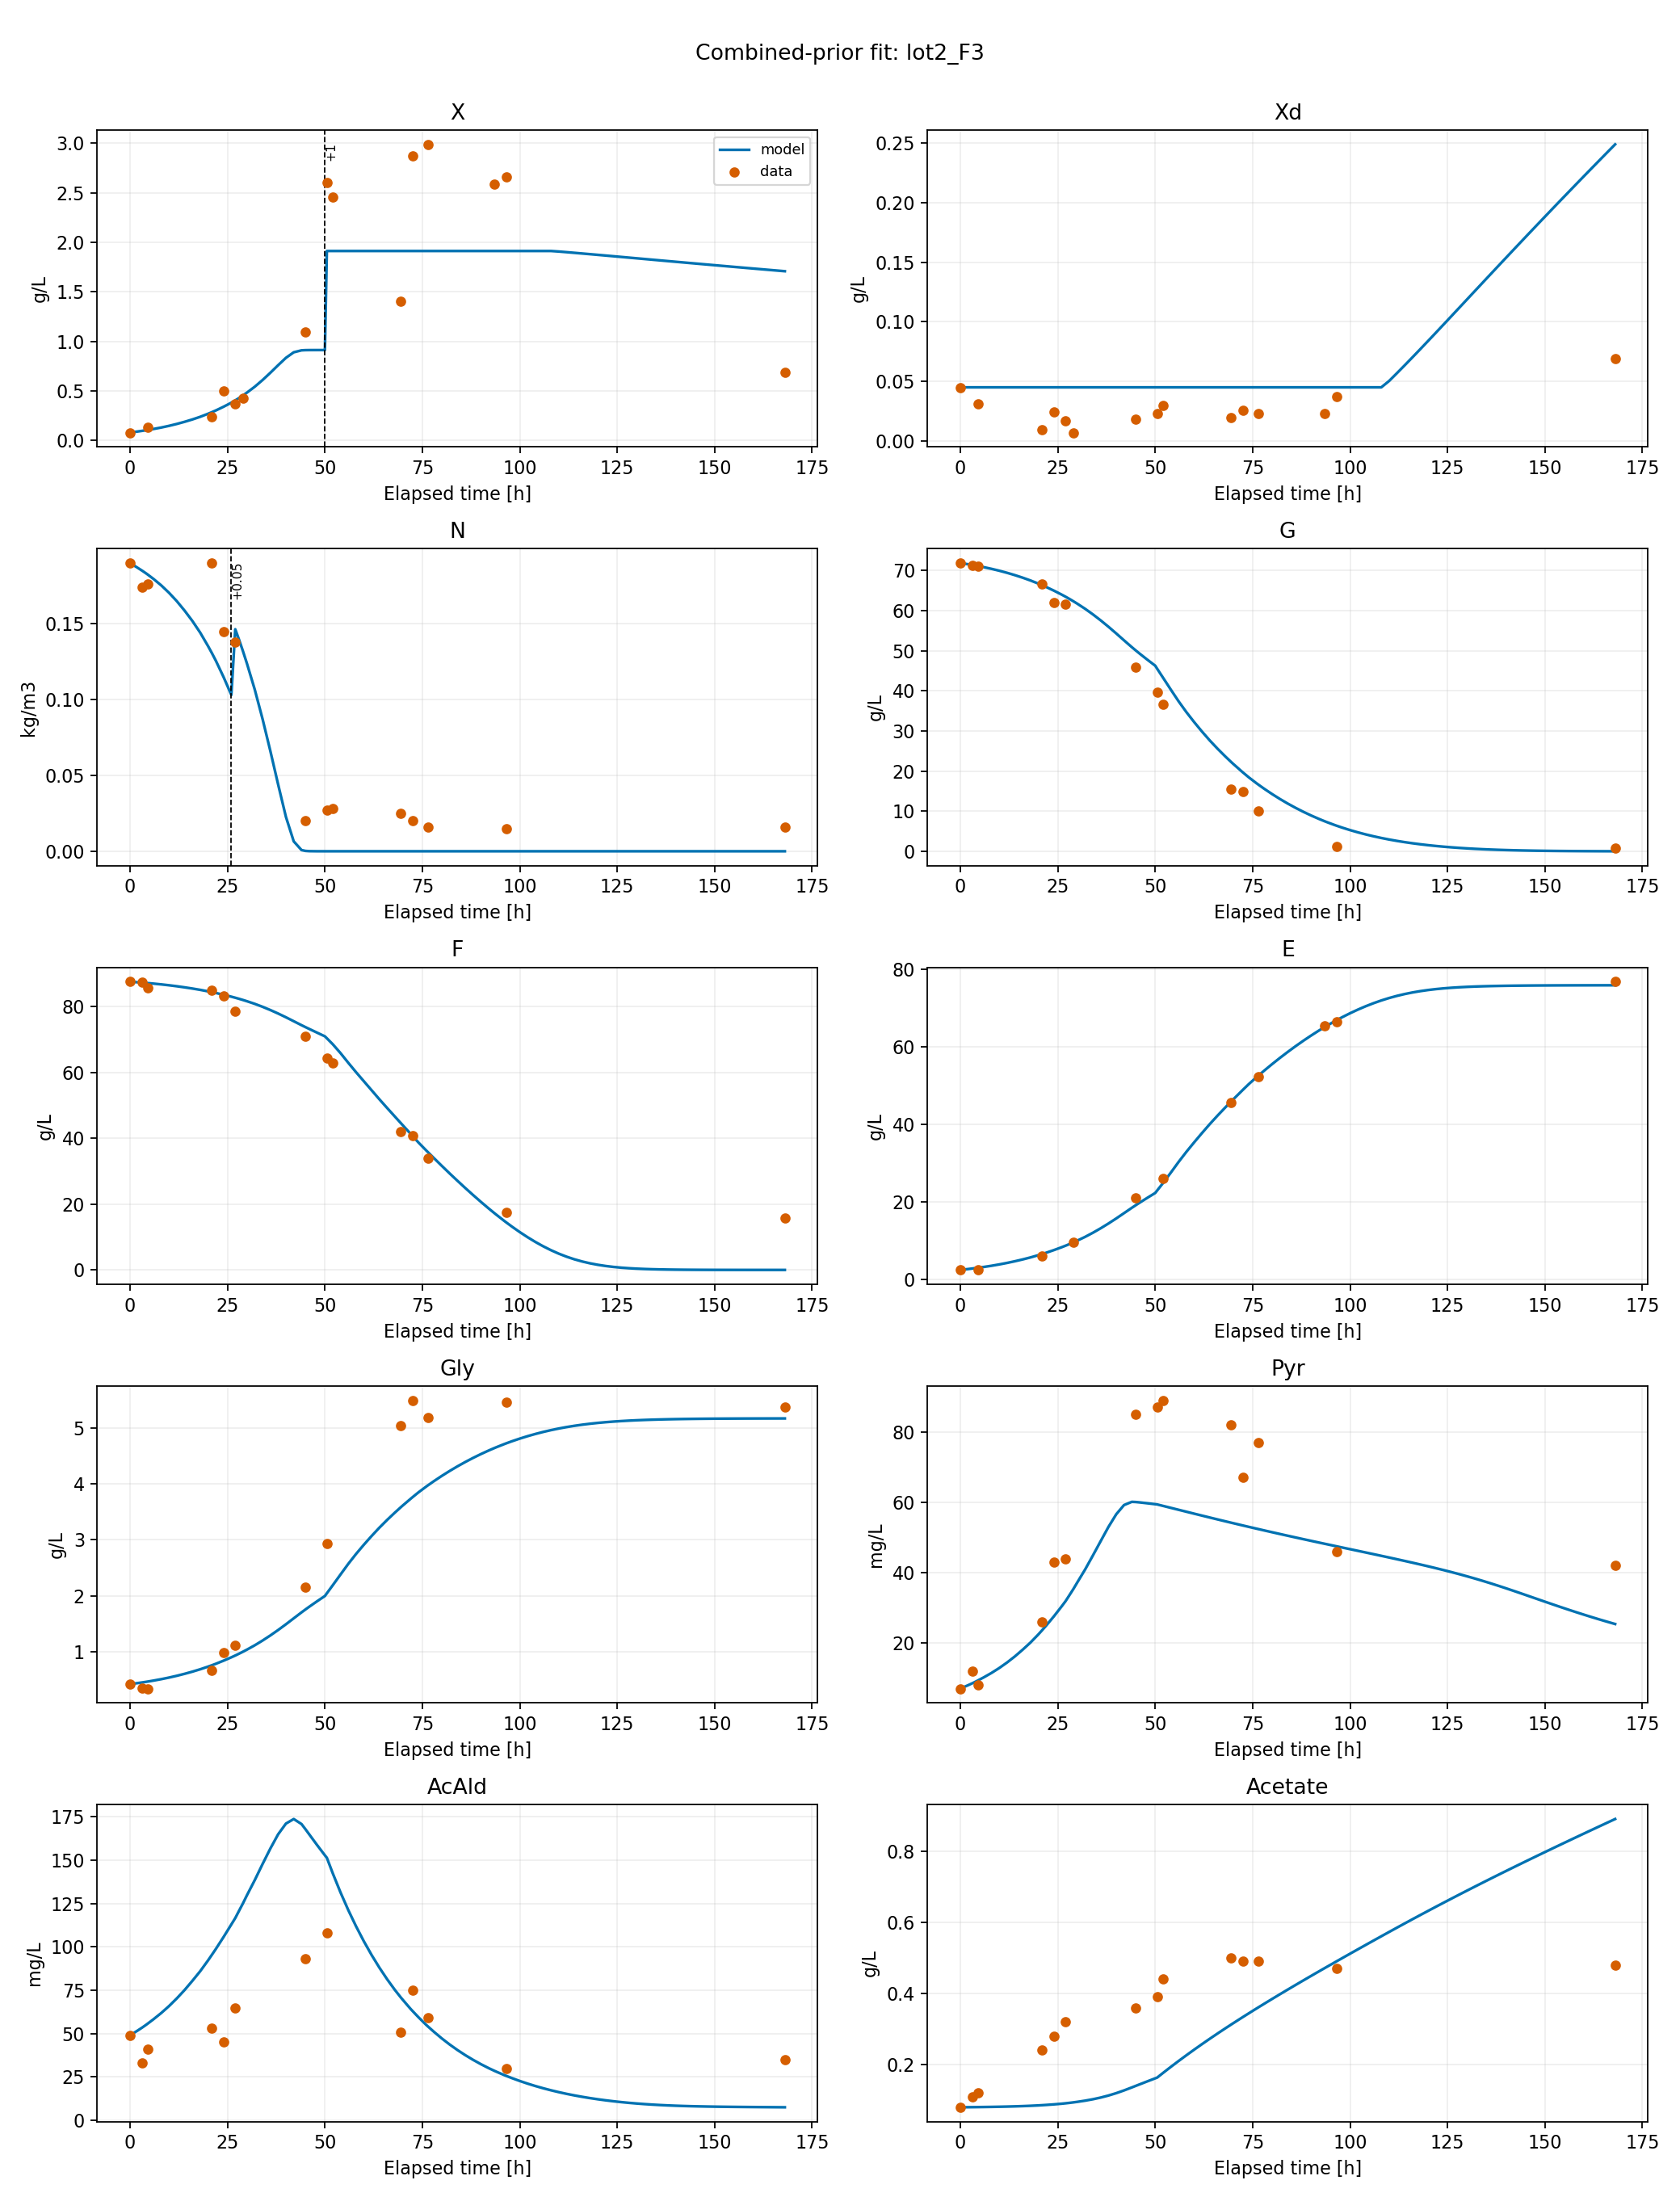

In [4]:
display(Image(filename=str(analysis.FIGURE_DIR / "estimability_historical_vs_plus_lot2.png")))
for process in ("F1", "F2", "F3"):
    display(Image(filename=str(analysis.FIGURE_DIR / "lot2_fit_overlays" / f"fit_lot2_{process}.png")))

## Takeaways

In [5]:
display(Markdown(analysis.REPORT_PATH.read_text(encoding="utf-8")))

# Historical synthetic prior plus MBDoE Lot 2

## Scope

The historical synthetic-must calibration is the prior dataset. The three executed Lot 2 MBDoE fermentations are then added with their reconstructed actual temperature profiles, observed sample times, model-safe chemistry, Oculyze biomass, and supported pulse schedule.

The 11-parameter core block and the reduced six-parameter secondary block are re-estimated. Aroma parameters are carried in the extended FIM but cannot gain observed-data information because Lot 2 does not contain aroma measurements.

## Core fit

| fit                            |   n_batches | mediums   | parameters                                             |   n_parameters | success   |   status | message                                    |   nfev |   initial_wsse |   final_wsse |   n_residuals |   dof |   wsse_per_residual |   wsse_per_dof |   l2_lambda |   l2_parameters | best_seed                  |
|:-------------------------------|------------:|:----------|:-------------------------------------------------------|---------------:|:----------|---------:|:-------------------------------------------|-------:|---------------:|-------------:|--------------:|------:|--------------------:|---------------:|------------:|----------------:|:---------------------------|
| historical_synthetic           |          10 | synthetic | mu0,qN,betaG0,betaF0,qEG,qEF,iG,iE,Kd0,gammaG0,gammaF0 |             11 | True      |        3 | `xtol` termination condition is satisfied. |      7 |        9304.15 |      9302.47 |           542 |   531 |             17.1632 |        17.5188 |           0 |             nan | profile_center_Kd0_release |
| historical_synthetic_plus_lot2 |          13 | synthetic | mu0,qN,betaG0,betaF0,qEG,qEF,iG,iE,Kd0,gammaG0,gammaF0 |             11 | True      |        3 | `xtol` termination condition is satisfied. |     24 |       26389    |     17876.9  |           849 |   838 |             21.0564 |        21.3328 |           0 |             nan | seed_default               |

## Secondary fit

| case                           | model                          | success   |   status | message                                    |   nfev |   initial_wsse |   final_wsse |   n_residuals |   wsse_per_residual |
|:-------------------------------|:-------------------------------|:----------|---------:|:-------------------------------------------|-------:|---------------:|-------------:|--------------:|--------------------:|
| historical_synthetic           | historical_synthetic           | True      |        2 | `ftol` termination condition is satisfied. |     18 |        914.871 |      596.654 |            86 |             6.93784 |
| historical_synthetic_plus_lot2 | historical_synthetic_plus_lot2 | True      |        2 | `ftol` termination condition is satisfied. |     14 |       7237.92  |     3996.7   |           215 |            18.5893  |

## Lot 2 measurement support

| process   | state   |   n_observations | used_in_core_fit   | used_in_secondary_fit   |
|:----------|:--------|-----------------:|:-------------------|:------------------------|
| F1        | X       |               17 | True               | False                   |
| F1        | Xd      |               17 | True               | False                   |
| F1        | N       |               14 | True               | False                   |
| F1        | G       |               15 | True               | False                   |
| F1        | F       |               15 | True               | False                   |
| F1        | E       |               13 | True               | False                   |
| F1        | Gly     |               15 | True               | False                   |
| F1        | Pyr     |               15 | False              | True                    |
| F1        | AcAld   |               14 | False              | True                    |
| F1        | Acetate |               15 | False              | True                    |
| F1        | O2      |                0 | False              | True                    |
| F2        | X       |               17 | True               | False                   |
| F2        | Xd      |               17 | True               | False                   |
| F2        | N       |               15 | True               | False                   |
| F2        | G       |               15 | True               | False                   |
| F2        | F       |               15 | True               | False                   |
| F2        | E       |               12 | True               | False                   |
| F2        | Gly     |               14 | True               | False                   |
| F2        | Pyr     |               15 | False              | True                    |
| F2        | AcAld   |               14 | False              | True                    |
| F2        | Acetate |               15 | False              | True                    |
| F2        | O2      |                0 | False              | True                    |
| F3        | X       |               15 | True               | False                   |
| F3        | Xd      |               15 | True               | False                   |
| F3        | N       |               14 | True               | False                   |
| F3        | G       |               14 | True               | False                   |
| F3        | F       |               14 | True               | False                   |
| F3        | E       |               11 | True               | False                   |
| F3        | Gly     |               13 | True               | False                   |
| F3        | Pyr     |               14 | False              | True                    |
| F3        | AcAld   |               13 | False              | True                    |
| F3        | Acetate |               14 | False              | True                    |
| F3        | O2      |                0 | False              | True                    |

## FIM metrics

|    logdet |   min_eigenvalue |   max_eigenvalue |   min_relative_eigenvalue |   condition_number |        trace_inv |   rank_1e-8 | case                                                        | block                   |   n_parameters |
|----------:|-----------------:|-----------------:|--------------------------:|-------------------:|-----------------:|------------:|:------------------------------------------------------------|:------------------------|---------------:|
| -105.62   |          0       |          94986.6 |               0           |              1e+12 |      1.77315e+06 |          13 | historical_observed_only_at_historical_theta                | extended                |             26 |
|  -92.1271 |          0       |         136089   |               0           |              1e+12 |      1.46333e+06 |          14 | historical_component_at_combined_theta                      | extended                |             26 |
|  -51.4506 |          0       |          39354.2 |               0           |              1e+12 |      3.16514e+06 |          17 | lot2_increment_observed_only_at_combined_theta              | extended                |             26 |
|  -15.8041 |          0       |         171849   |               0           |              1e+12 | 814927           |          17 | combined_observed_only_at_combined_theta                    | extended                |             26 |
|  -51.0357 |          0       |          40099.5 |               0           |              1e+12 |      3.10553e+06 |          17 | lot2_increment_observed_plus_co2_schedule_at_combined_theta | extended                |             26 |
|  -15.6925 |          0       |         172219   |               0           |              1e+12 | 810919           |          17 | combined_observed_plus_co2_schedule_at_combined_theta       | extended                |             26 |
|   82.8658 |          8.08458 |         165350   |               4.88937e-05 |          20452.5   |      0.158097    |          11 | historical_synthetic_plus_lot2                              | core                    |             11 |
|  124.386  |          8.30236 |         171849   |               4.8312e-05  |          20698.8   |      0.211106    |          17 | historical_synthetic_plus_lot2                              | core_secondary_observed |             17 |

The observed core-plus-secondary block is locally full rank: `17/17`. The full matrix is rank `17/26` because the nine aroma columns are exactly unsupported. Adding CO2 measurement times without fitting a gas-flow observation equation leaves the rank unchanged and reduces `trace_inv` by only `0.492%`.

## Largest uncertainty reductions

| parameter       |   std_log_historical |   std_log_combined |   std_log_ratio_combined_over_historical | classification_combined   |
|:----------------|---------------------:|-------------------:|-----------------------------------------:|:--------------------------|
| kAldS_N         |          382.212     |          0.0288899 |                              7.5586e-05  | well_estimated            |
| kAcAld          |          382.212     |          0.0378128 |                              9.89315e-05 | well_estimated            |
| kAcStress       |          382.212     |          0.0392821 |                              0.000102776 | well_estimated            |
| gammaF0         |          141.822     |          0.339697  |                              0.00239524  | well_estimated            |
| kPyrS_N         |            0.0472078 |          0.0303959 |                              0.643875    | well_estimated            |
| betaG0          |            0.0584868 |          0.0417328 |                              0.713542    | well_estimated            |
| qEG             |            0.0445067 |          0.0330575 |                              0.742754    | well_estimated            |
| iE              |            0.0588404 |          0.0439056 |                              0.746181    | well_estimated            |
| mu0             |            0.0144019 |          0.0112885 |                              0.783816    | well_estimated            |
| alpha_EA_loss   |          382.212     |        300.911     |                              0.787288    | weak_or_confounded        |
| k_EO_stationary |          382.212     |        300.911     |                              0.787288    | weak_or_confounded        |
| k_EO_growth     |          382.212     |        300.911     |                              0.787288    | weak_or_confounded        |

## Remaining weak directions

| parameter        |   std_log_combined |   approx_95_multiplier_combined | active_bound_combined   | classification_combined   |
|:-----------------|-------------------:|--------------------------------:|:------------------------|:--------------------------|
| alpha_EO_loss    |         300.911    |                     1.05765e+17 | False                   | weak_or_confounded        |
| alpha_IAA_loss   |         300.911    |                     1.05765e+17 | False                   | weak_or_confounded        |
| alpha_EA_loss    |         300.911    |                     1.05765e+17 | False                   | weak_or_confounded        |
| k_EO_stationary  |         300.911    |                     1.05765e+17 | False                   | weak_or_confounded        |
| k_EO_growth      |         300.911    |                     1.05765e+17 | False                   | weak_or_confounded        |
| k_IAA_stationary |         300.911    |                     1.05765e+17 | False                   | weak_or_confounded        |
| k_IAA_growth     |         300.911    |                     1.05765e+17 | False                   | weak_or_confounded        |
| k_EA_stationary  |         300.911    |                     1.05765e+17 | False                   | weak_or_confounded        |
| k_EA_growth      |         300.911    |                     1.05765e+17 | False                   | weak_or_confounded        |
| gammaF0          |           0.339697 |                     1.94606     | False                   | well_estimated            |
| kPyrO2           |           0.206419 |                     1.49867     | False                   | well_estimated            |
| betaF0           |           0.107792 |                     1.23525     | False                   | well_estimated            |

## Dispersion-adjusted screening

The unscaled FIM assumes that the residual noise model is correct. It is not: core WSSE/DOF is `21.333` and secondary WSSE/residual is `18.589`. The table below multiplies local standard errors by the corresponding square-root dispersion. This is the safer practical-identifiability classification until model discrepancy and analytical error are separated.

| parameter   |   std_log_combined |   dispersion_scale_combined |   std_log_dispersion_adjusted |   approx_95_multiplier_dispersion_adjusted | classification_dispersion_adjusted   |
|:------------|-------------------:|----------------------------:|------------------------------:|-------------------------------------------:|:-------------------------------------|
| mu0         |          0.0112885 |                     4.61875 |                     0.0521386 |                                    1.1076  | well_estimated                       |
| qN          |          0.0128896 |                     4.61875 |                     0.0595339 |                                    1.12377 | well_estimated                       |
| kAldS_N     |          0.0288899 |                     4.31153 |                     0.12456   |                                    1.27652 | well_estimated                       |
| kPyrS_N     |          0.0303959 |                     4.31153 |                     0.131053  |                                    1.29287 | well_estimated                       |
| qEG         |          0.0330575 |                     4.61875 |                     0.152684  |                                    1.34886 | well_estimated                       |
| kAcAld      |          0.0378128 |                     4.31153 |                     0.163031  |                                    1.3765  | well_estimated                       |
| kAcStress   |          0.0392821 |                     4.31153 |                     0.169366  |                                    1.39369 | well_estimated                       |
| betaG0      |          0.0417328 |                     4.61875 |                     0.192753  |                                    1.45907 | well_estimated                       |
| gammaG0     |          0.042123  |                     4.61875 |                     0.194556  |                                    1.46423 | well_estimated                       |
| iE          |          0.0439056 |                     4.61875 |                     0.202789  |                                    1.48805 | well_estimated                       |
| Kd0         |          0.0479251 |                     4.61875 |                     0.221354  |                                    1.54319 | well_estimated                       |
| qEF         |          0.0869286 |                     4.61875 |                     0.401501  |                                    2.19667 | moderate                             |
| iG          |          0.0965827 |                     4.61875 |                     0.446091  |                                    2.39729 | moderate                             |
| kPyrDrain   |          0.103639  |                     4.31153 |                     0.446841  |                                    2.40082 | moderate                             |
| betaF0      |          0.107792  |                     4.61875 |                     0.497863  |                                    2.65332 | moderate                             |
| kPyrO2      |          0.206419  |                     4.31153 |                     0.889981  |                                    5.72225 | weak_but_actionable                  |
| gammaF0     |          0.339697  |                     4.61875 |                     1.56898   |                                   21.6541  | weak_or_confounded                   |

## Profile likelihood

| case                           | parameter   |   n_success |   max_lr_stat | crosses_left_95   | crosses_right_95   | profile_identifiable_95   |   chi2_95_threshold |
|:-------------------------------|:------------|------------:|--------------:|:------------------|:-------------------|:--------------------------|--------------------:|
| historical_synthetic_plus_lot2 | Kd0         |           4 |       294.654 | True              | True               | True                      |             3.84146 |
| historical_synthetic_plus_lot2 | qN          |           4 |      1796.96  | True              | True               | True                      |             3.84146 |

## Weak eigen-directions after Lot 2

| case                           |   weak_direction |   eigenvalue | dominant_parameters                                               | dominant_abs_loadings                           |
|:-------------------------------|-----------------:|-------------:|:------------------------------------------------------------------|:------------------------------------------------|
| historical_synthetic_plus_lot2 |                1 |            0 | k_EA_growth, alpha_EO_loss, kPyrS_N, qN, betaG0, betaF0, qEG      | 1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000 |
| historical_synthetic_plus_lot2 |                2 |            0 | k_EA_stationary, alpha_EO_loss, kPyrS_N, qN, betaG0, betaF0, qEG  | 1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000 |
| historical_synthetic_plus_lot2 |                3 |            0 | k_IAA_growth, alpha_EO_loss, kPyrS_N, qN, betaG0, betaF0, qEG     | 1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000 |
| historical_synthetic_plus_lot2 |                4 |            0 | k_IAA_stationary, alpha_EO_loss, kPyrS_N, qN, betaG0, betaF0, qEG | 1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000 |
| historical_synthetic_plus_lot2 |                5 |            0 | k_EO_growth, alpha_EO_loss, kPyrS_N, qN, betaG0, betaF0, qEG      | 1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000 |
| historical_synthetic_plus_lot2 |                6 |            0 | k_EO_stationary, alpha_EO_loss, kPyrS_N, qN, betaG0, betaF0, qEG  | 1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000 |
| historical_synthetic_plus_lot2 |                7 |            0 | alpha_EA_loss, alpha_EO_loss, kPyrS_N, qN, betaG0, betaF0, qEG    | 1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000 |
| historical_synthetic_plus_lot2 |                8 |            0 | alpha_IAA_loss, alpha_EO_loss, qN, betaG0, betaF0, qEG, qEF       | 1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000 |

## Interpretation

- `observed_only` is the defensible practical-identifiability result for the measurements currently linked to the model.
- `observed_plus_CO2_schedule` is a conditional sensitivity calculation. CO2 flow values are not fitted as cumulative CO2 until a gas-flow observation equation is calibrated.
- The FIM is also decomposed at the combined parameter point. Therefore, `historical_component_at_combined_theta + lot2_increment_at_combined_theta` reproduces the combined FIM and isolates the information supplied by Lot 2 from changes in the optimum.
- Nitrogen pulse timing in F1/F3 remains protocol-based; the F1 fructose pulse and F3 viable-biomass step have direct trajectory evidence.
- One F2 ethanol point at 168 h is visible in the QC notebook but excluded by the conservative sugar/ethanol screen.
- Numerical convergence and full local rank do not imply that the current equations fit every state adequately. F1 glucose, residual YAN, late dead biomass, pyruvate, acetaldehyde, and acetate retain visible systematic error.
- `kPyrO2` is only indirectly informed because Lot 2 contains no DO observations and the oxygen-transfer parameters remain fixed. Treat its adjusted classification as conditional on that fixed oxygen submodel.
